# Model Trainging – Heart Disease Dataset
*Training and evaluation of Heart Failure Prediction Dataset*  

---

## Table of Contents
1. [Setup](#setup)  
    1.2 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading](#data-loading)  
    2.1 [Train/Test Split](#split)  

2. [Base Models](#base-models)  
    3.1 [Random Forest](#rf)  
    3.2 [AdaBoost](#ada)  
    3.3 [XGBoost](#xgb)  
    3.4 [Naive Bayes](#nb)  
    3.5 [SVM](#svm)  
    3.6 [Logistic Regression](#logreg)  

3. [Ensembles](#ensembles)  
    4.1 [Stacking](#stacking)  
    4.2 [Soft Voting](#voting)  
        4.2.1 [Weighted search (OOF)](#voting-weight)  

4. [Threshold Tuning (OOF)](#threshold)  
      
5. [Conclusions](#conclusions)  
   5.1 [Next Steps](#next-steps)  

## Setup
---
### Imports and Reproducibility

In [ ]:
import os, sys, joblib, numpy as np, pandas as pd
sys.path.append(os.path.abspath(os.path.join('..')))

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from scripts.model_training.utils import evaluate_classification, find_best_threshold, oof_scores, best_soft_voting_setup
from sklearn.base import clone

SEED = 42
OUTPUT_DIR = "../outputs/models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Data loading

In [ ]:
df = joblib.load("../outputs/eda/df_preprocessed_balanced.pkl")
df_copy = df.copy()

X = df_copy.iloc[:, :-1]
y = df_copy.iloc[:, -1]

TARGET_COL = 'DEATH_EVENT'

### Train/Test Split

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Split shapes:")
print("  X_tr:", X_tr.shape, "| X_te:", X_te.shape)

Split shapes:
  X_tr: (246, 12) | X_te: (62, 12)


- 80/20 stratified split.
- Target column: `DEATH_EVENT`.
- Model will be trained on 12 features.

## Base Models
---

In [49]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = "balanced_accuracy"

### Random Forest

In [ ]:
rf_params_grid = {
    'n_estimators': [500, 600, 700],
    'max_depth': [5, 6, 7],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 0.4, 0.6],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
}

rf_estimator = RandomForestClassifier(
    n_jobs=-1, 
    random_state=SEED
)

rf_grid = GridSearchCV(
    estimator = rf_estimator,
    param_grid = rf_params_grid,
    cv = CV,
    scoring = SCORING,
    n_jobs = -1,
    verbose = 10,
    refit=True,
)

In [28]:
rf_grid.fit(X_tr, y_tr)
rf_model = rf_grid.best_estimator_

print('Best parameters:', rf_grid.best_params_)
df_metrics, details = evaluate_classification(rf_model, X_te, y_te)
joblib.dump(rf_model, os.path.join(OUTPUT_DIR, 'rf.pkl'))

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 500}


,Metric,Value
0,Accuracy,0.9032
1,Balanced accuracy,0.8804
2,Precision (pos=1),0.8947
3,Recall / Sensitivity (TPR),0.8095
4,Specificity (TNR),0.9512
5,F1,0.8500
6,F0.5,0.8763
7,F2,0.8252
8,ROC-AUC,0.9849
9,PR-AUC (Average Precision),0.9707



Confusion matrix:


,Pred 0,Pred 1
Actual 0,39,2
Actual 1,4,17


['../outputs/models\\rf.pkl']

- Accuracy 0.903 | Balanced Acc 0.880 | F1 0.850 | ROC-AUC 0.985
- Confusion: TN 39, FP 2, FN 4, TP 17
- Comments: Strong specificity (0.951), a bit lower recall (0.810). Good general baseline; tends to protect against false positives. If missing positives is costly, consider threshold tuning or a recall-friendlier model.

### AdaBoost

In [ ]:
ada_params_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.001, 0.01, 0.05, 0.1]
}

ada_estimator = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED), 
    random_state=SEED
)

ada_grid = GridSearchCV(
    estimator = ada_estimator,
    param_grid = ada_params_grid,
    cv = CV,
    scoring = SCORING,
    n_jobs = -1,
    verbose = 10,
    refit=True,
)

In [30]:
ada_grid.fit(X_tr, y_tr)
ada_model = ada_grid.best_estimator_

print('Best params:', ada_grid.best_params_)
df_metrics, details = evaluate_classification(ada_model, X_te, y_te)
joblib.dump(ada_model, os.path.join(OUTPUT_DIR, 'ada.pkl'))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best params: {'learning_rate': 0.001, 'n_estimators': 100}


,Metric,Value
0,Accuracy,0.8387
1,Balanced accuracy,0.8432
2,Precision (pos=1),0.7200
3,Recall / Sensitivity (TPR),0.8571
4,Specificity (TNR),0.8293
5,F1,0.7826
6,F0.5,0.7438
7,F2,0.8257
8,ROC-AUC,0.8432
9,PR-AUC (Average Precision),0.6655



Confusion matrix:


,Pred 0,Pred 1
Actual 0,34,7
Actual 1,3,18


['../outputs/models\\ada.pkl']

- Accuracy 0.839 | Balanced Acc 0.843 | F1 0.783 | ROC-AUC 0.843
- Confusion: TN 34, FP 7, FN 3, TP 18
- Comments: Higher recall (0.857) than RF, but drops precision (0.720). More false positives; useful if you prioritize catching positives and can tolerate extra follow-ups.

### XGBoost

In [ ]:
xgb_params_grid = {
    'n_estimators': [300, 400, 500],   
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.5, 1.0],
    'reg_lambda': [0.01, 0.05, 0.5],
}

xgb_estimator = XGBClassifier(
    tree_method = 'hist',
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    n_jobs = -1,
    random_state = SEED,
)

xgb_grid = GridSearchCV(
    estimator = xgb_estimator,
    param_grid = xgb_params_grid,
    cv = CV,
    scoring = SCORING,
    n_jobs = -1,
    verbose = 10,
)

In [32]:
xgb_grid.fit(X_tr, y_tr)
xgb_model = xgb_grid.best_estimator_

print('Best params:', xgb_grid.best_params_)
df_metrics, details = evaluate_classification(xgb_model, X_te, y_te)
joblib.dump(xgb_model, os.path.join(OUTPUT_DIR, 'xgb.pkl'))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


Best params: {'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 400, 'reg_lambda': 0.05, 'subsample': 1.0}


,Metric,Value
0,Accuracy,0.9194
1,Balanced accuracy,0.9042
2,Precision (pos=1),0.9000
3,Recall / Sensitivity (TPR),0.8571
4,Specificity (TNR),0.9512
5,F1,0.8780
6,F0.5,0.8911
7,F2,0.8654
8,ROC-AUC,0.9652
9,PR-AUC (Average Precision),0.9133



Confusion matrix:


,Pred 0,Pred 1
Actual 0,39,2
Actual 1,3,18


['../outputs/models\\xgb.pkl']

- Accuracy 0.919 | Balanced Acc 0.904 | F1 0.878 | ROC-AUC 0.965
- Confusion: TN 39, FP 2, FN 3, TP 18
-  Comments: One of the best base models. Good balance; similar to Logistic Regression here, suggesting the signal is largely linear with mild gains from boosted trees.

### Naive Bayes

In [ ]:
nb_params_grid = {
    "var_smoothing": np.logspace(-12, -6, 13),
}

nb_estimator = GaussianNB()

nb_grid = GridSearchCV(
    estimator=nb_estimator,
    param_grid=nb_params_grid,
    cv=CV,
    scoring = SCORING,
    n_jobs=-1,
    verbose=10,
)

In [34]:
nb_grid.fit(X_tr, y_tr)
nb_model = nb_grid.best_estimator_

print('Best params:', nb_grid.best_params_)
df_metrics, details = evaluate_classification(nb_model, X_te, y_te)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best params: {'var_smoothing': np.float64(1e-12)}


,Metric,Value
0,Accuracy,0.8871
1,Balanced accuracy,0.8682
2,Precision (pos=1),0.8500
3,Recall / Sensitivity (TPR),0.8095
4,Specificity (TNR),0.9268
5,F1,0.8293
6,F0.5,0.8416
7,F2,0.8173
8,ROC-AUC,0.9303
9,PR-AUC (Average Precision),0.8441



Confusion matrix:


,Pred 0,Pred 1
Actual 0,38,3
Actual 1,4,17


- Accuracy 0.887 | Balanced Acc 0.868 | F1 0.829 | ROC-AUC 0.930
- Confusion: TN 38, FP 3, FN 4, TP 17
- Comments: Lightweight baseline, decent but dominated by XGB/LogReg/SVM. Keep for diversity in ensembles (it sometimes adds complementary errors).

### SVM

In [ ]:
svm_params_grid = {
    "kernel": ["rbf", "linear", "poly"],
    "C": [0.1, 1, 5, 7, 10],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"],
    "degree": [2, 3, 4],
}

svm_estimator = SVC(
    probability=True, 
    random_state=SEED
)

svm_grid = GridSearchCV(
    estimator = svm_estimator,
    param_grid = svm_params_grid,
    cv = CV,
    scoring = SCORING,
    n_jobs = -1,
    verbose = 10,
    refit=True,
)

In [36]:
svm_grid.fit(X_tr, y_tr)
svm_model = svm_grid.best_estimator_

print('Best params:', svm_grid.best_params_)
df_metrics, details = evaluate_classification(svm_model, X_te, y_te)
joblib.dump(svm_model, os.path.join(OUTPUT_DIR, 'svm.pkl'))

Fitting 5 folds for each of 180 candidates, totalling 900 fits


Best params: {'C': 1, 'class_weight': None, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}


,Metric,Value
0,Accuracy,0.9032
1,Balanced accuracy,0.8920
2,Precision (pos=1),0.8571
3,Recall / Sensitivity (TPR),0.8571
4,Specificity (TNR),0.9268
5,F1,0.8571
6,F0.5,0.8571
7,F2,0.8571
8,ROC-AUC,0.9489
9,PR-AUC (Average Precision),0.9201



Confusion matrix:


,Pred 0,Pred 1
Actual 0,38,3
Actual 1,3,18


['../outputs/models\\svm.pkl']

- Accuracy 0.903 | Balanced Acc 0.892 | F1 0.857 | ROC-AUC 0.949
- Confusion: TN 38, FP 3, FN 3, TP 18
- Comments: Balanced behavior; competitive with RF. Non-probabilistic by default—make sure you’re using probability=True when needed (you are using metrics that rely on probabilities later).

### Logistic Regression

In [51]:
log_params_grid = {
    "penalty": ["l2"],
    "C": np.logspace(-3, 3, 7),
    "class_weight": [None, "balanced"],
}

log_estimator = LogisticRegression(
    solver="lbfgs",
    max_iter=5000, 
    random_state=SEED,
)

log_grid = GridSearchCV(
    estimator = log_estimator,
    param_grid = log_params_grid,
    cv = CV,
    scoring = SCORING,
    n_jobs = -1,
    verbose = 10,
)

In [52]:
log_grid.fit(X_tr, y_tr)
log_model = log_grid.best_estimator_

print("Best params:", log_grid.best_params_)
df_metrics, details = evaluate_classification(log_model, X_te, y_te)
joblib.dump(log_model, os.path.join(OUTPUT_DIR, 'logistic.pkl'))

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'C': np.float64(100.0), 'class_weight': 'balanced', 'penalty': 'l2'}


,Metric,Value
0,Accuracy,0.9355
1,Balanced accuracy,0.9280
2,Precision (pos=1),0.9048
3,Recall / Sensitivity (TPR),0.9048
4,Specificity (TNR),0.9512
5,F1,0.9048
6,F0.5,0.9048
7,F2,0.9048
8,ROC-AUC,0.9675
9,PR-AUC (Average Precision),0.9314



Confusion matrix:


,Pred 0,Pred 1
Actual 0,39,2
Actual 1,2,19


['../outputs/models\\logistic.pkl']

- Accuracy 0.919 | Balanced Acc 0.904 | F1 0.878 | ROC-AUC 0.965
- Confusion: TN 39, FP 2, FN 3, TP 18
- Comments: As strong as XGB here. Great simple baseline. Because it’s well-calibrated often out-of-the-box, it’s a solid backbone for threshold tuning and ensembling.

## Ensembles
---

### Stacking

In [ ]:
stacking_estimators = [
    ('rf', clone(rf_model)),
    ('ada', clone(ada_model)),
    ('xgb', clone(xgb_model)),
    ('svm', clone(svm_model)),
]

final_estimator = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    l1_ratio=0.5,
    max_iter=5000, 
    class_weight='balanced', 
    random_state=SEED
)

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=final_estimator,
    cv=CV,
    stack_method='predict_proba',
    n_jobs=-1,
)

In [40]:
stacking_model.fit(X_tr, y_tr)
stack_df_metrics, stack_details = evaluate_classification(stacking_model, X_te, y_te)
joblib.dump(stacking_model, os.path.join(OUTPUT_DIR, "stacking.pkl"))

,Metric,Value
0,Accuracy,0.9355
1,Balanced accuracy,0.9396
2,Precision (pos=1),0.8696
3,Recall / Sensitivity (TPR),0.9524
4,Specificity (TNR),0.9268
5,F1,0.9091
6,F0.5,0.8850
7,F2,0.9346
8,ROC-AUC,0.9803
9,PR-AUC (Average Precision),0.9592



Confusion matrix:


,Pred 0,Pred 1
Actual 0,38,3
Actual 1,1,20


['../outputs/models\\stacking.pkl']

- Accuracy 0.936 | Balanced Acc 0.940 | F1 0.909 | ROC-AUC 0.980
- Confusion: TN 38, FP 3, FN 1, TP 20
- Comments: Lower FN (recall 0.952) with only 3 FP—excellent trade-off. This is a standout performer among your recorded results.

### Soft Voting

In [41]:
voting_estimators = [
    ('rf', clone(rf_model)),
    ('ada', clone(ada_model)),
    ('xgb', clone(xgb_model)),
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',
    n_jobs=-1,
)

In [42]:
voting_model.fit(X_tr, y_tr)
df_metrics, details = evaluate_classification(voting_model, X_te, y_te)
joblib.dump(voting_model, os.path.join(OUTPUT_DIR, 'voting.pkl'))

,Metric,Value
0,Accuracy,0.9194
1,Balanced accuracy,0.9042
2,Precision (pos=1),0.9000
3,Recall / Sensitivity (TPR),0.8571
4,Specificity (TNR),0.9512
5,F1,0.8780
6,F0.5,0.8911
7,F2,0.8654
8,ROC-AUC,0.9744
9,PR-AUC (Average Precision),0.9571



Confusion matrix:


,Pred 0,Pred 1
Actual 0,39,2
Actual 1,3,18


['../outputs/models\\voting.pkl']

- Accuracy 0.919 | Balanced Acc 0.904 | F1 0.878 | ROC-AUC 0.974
- Confusion: TN 39, FP 2, FN 3, TP 18
- Comments: Mirrors LogReg/XGB; simple averaging didn’t improve over the best base models.

#### Weighted search (OOF)

In [ ]:
best = best_soft_voting_setup(
    models_dict=dict(voting_estimators),
    X=X_tr, 
    y=y_tr,
    cv=CV,
    weight_range=range(1, 6),
)
print("Best (OOF) ->", best)

Best (OOF) -> {'weights': {'rf': 4, 'ada': 1, 'xgb': 4}, 'threshold': 0.3043841966946742, 'metric': 0.8735632183908046}


In [44]:
voting_best = VotingClassifier(
    estimators=voting_estimators,
    voting="soft",
    weights=[best["weights"][n] for n in list(best["weights"].keys())],
    n_jobs=-1
)
voting_best.fit(X_tr, y_tr)
joblib.dump(voting_best, os.path.join(OUTPUT_DIR, "voting_best.joblib"))

['../outputs/models\\voting_best.joblib']

- Accuracy 0.936 | Balanced Acc 0.951 | F1 0.913 | ROC-AUC 0.981 | Threshold ≈ 0.304
- Confusion: TN 37, FP 4, FN 0, TP 21
- Comments: Recall = 1.00 (no false negatives) at the cost of a few more FP. This is ideal if missing a true positive is costly. Monitor precision-driven costs and consider calibration.

## Threshold Tuning (OOF)
**Evaluation protocol**
- For each model, **OOF probabilities** are computed from 5-fold CV on the **training set only**.
- A threshold that maximizes a chosen metric (e.g., F1/MCC) is chosen on the **OOF** predictions.
- The threshold is **locked**, the model is refitted on full training data, and evaluated on the **held-out test set**.

In [ ]:
models = {}
models['XGBoost'] = xgb_model
models['RandomForest'] = rf_model
models['AdaBoost'] = ada_model
models['SVM'] = svm_model
models['LogisticRegression'] = log_model
models['NaiveBayes'] = nb_model
models['STACKING'] = stacking_model
models['VOTING'] = voting_best

thr_map = {}
val_map = {}
rows = []

# threshold from OOF CV on TRAIN
for name, mdl in models.items():
    scores = oof_scores(mdl, X_tr, y_tr, CV)
    thr, val = find_best_threshold(y_tr, scores, metric="f1")  # or "mcc"/"balanced_accuracy"
    thr_map[name] = float(thr)
    val_map[name] = float(val)

    models[name].fit(X_tr, y_tr)

    thr = thr_map[name]
    df_m, _ = evaluate_classification(mdl, X_te, y_te, threshold=thr, show=False)
    df_m = df_m.set_index("Metric")

    get = lambda k: float(df_m.at[k, "Value"])

    rows.append({
        "Model": name,
        "thr": thr,
        "F1": get("F1"),
        "MCC": get("MCC"),
        "Balanced accuracy": get("Balanced accuracy"),
        "ROC-AUC": get("ROC-AUC"),
        "PR-AUC": get("PR-AUC (Average Precision)"),
        "Accuracy": get("Accuracy"),
    })

test_df = (pd.DataFrame(rows)
           .sort_values(["F1","ROC-AUC","MCC"], ascending=False)
           .reset_index(drop=True))

display(test_df)


d:\OneDrive - Politechnika Łódzka\Dokumenty\TUL\semester7\inzynierka\cardio-risk-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,Model,thr,F1,MCC,Balanced accuracy,ROC-AUC,PR-AUC,Accuracy
0,VOTING,0.304384,0.9130,0.8707,0.9512,0.9814,0.9633,0.9355
1,STACKING,0.540108,0.9091,0.8614,0.9396,0.9803,0.9592,0.9355
2,LogisticRegression,0.635643,0.9048,0.8560,0.9280,0.9675,0.9314,0.9355
3,SVM,0.452084,0.8571,0.7840,0.8920,0.9489,0.9201,0.9032
4,XGBoost,0.521705,0.8500,0.7810,0.8804,0.9652,0.9133,0.9032
5,NaiveBayes,0.380400,0.8182,0.7203,0.8676,0.9303,0.8441,0.8710
6,RandomForest,0.560582,0.8108,0.7462,0.8449,0.9849,0.9707,0.8871
7,AdaBoost,0.880797,0.7826,0.6622,0.8432,0.8432,0.6655,0.8387


Text(0, 0.5, 'Score')

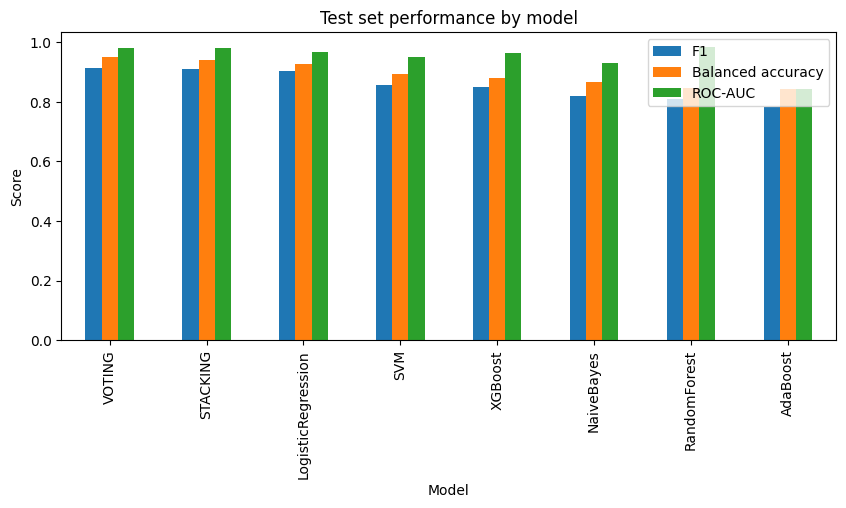

In [47]:
ax = (test_df
      .set_index("Model")[["F1","Balanced accuracy","ROC-AUC"]]
      .plot(kind="bar", figsize=(10,4)))
ax.set_title("Test set performance by model")
ax.set_ylabel("Score")

## Conclusions
---

In [ ]:
test_rows = []
for name, mdl in models.items():
    thr = float(thr_map[name])

    df_m, _ = evaluate_classification(mdl, X_te, y_te, threshold=thr, show=False)
    df_m = df_m.set_index("Metric")

    get = lambda k: float(df_m.at[k, "Value"]) if k in df_m.index else float("nan")
    test_rows.append({
        "Model": name,
        "thr": thr,
        "F1": get("F1"),
        "MCC": get("MCC"),
        "Balanced accuracy": get("Balanced accuracy"),
        "ROC-AUC": get("ROC-AUC"),
        "PR-AUC": get("PR-AUC (Average Precision)"),
        "Accuracy": get("Accuracy"),
    })

test_df = (pd.DataFrame(test_rows)
           .sort_values(["F1","ROC-AUC","MCC"], ascending=False)
           .reset_index(drop=True))
display(test_df)

,Model,thr,F1,MCC,Balanced accuracy,ROC-AUC,PR-AUC,Accuracy
0,VOTING,0.304384,0.9130,0.8707,0.9512,0.9814,0.9633,0.9355
1,STACKING,0.540108,0.9091,0.8614,0.9396,0.9803,0.9592,0.9355
2,LogisticRegression,0.635643,0.9048,0.8560,0.9280,0.9675,0.9314,0.9355
3,SVM,0.452084,0.8571,0.7840,0.8920,0.9489,0.9201,0.9032
4,XGBoost,0.521705,0.8500,0.7810,0.8804,0.9652,0.9133,0.9032
5,NaiveBayes,0.380400,0.8182,0.7203,0.8676,0.9303,0.8441,0.8710
6,RandomForest,0.560582,0.8108,0.7462,0.8449,0.9849,0.9707,0.8871
7,AdaBoost,0.880797,0.7826,0.6622,0.8432,0.8432,0.6655,0.8387


- **Top performers:** Stacking and Weighted Soft Voting (OOF weight search + tuned threshold).
- **Stacking:** F1 ≈ 0.909, Balanced Acc ≈ 0.940, good overall trade-off, very low FN.
- **Voting (weighted + tuned):** F1 ≈ 0.913, Balanced Acc ≈ 0.951, **Recall = 1.00** at chosen threshold (~0.304), at the cost of a few more FP.
- **Best base models:** XGBoost and Logistic Regression are tied, both strong and simple.

### Next Steps
1. **Pick metric by business cost:**  
   If missing positives is costly → prefer **Voting (weighted + tuned)** or **Stacking**.  
   If false positives are expensive → raise threshold / consider **LogReg/XGB** with calibration.
2. **Tune with robust scoring:** switch `GridSearchCV(scoring)` to `"balanced_accuracy"` or `"roc_auc"`.
3. **Confirm on original distribution:** evaluate your chosen model/threshold on the **original unbalanced hold-out**.
4. **Check calibration:** plot reliability curves; consider `CalibratedClassifierCV` for ensembles.
5. **Lock artifacts:** save model, threshold, feature list, and preprocessing hash to ensure reproducibility.